# Notebook 2 — Detección de anomalías en datos EFES
## Contexto

El sistema **EFES (Enfermedad Febril con Exantema)** registra casos sospechosos
de sarampión en México por estado y municipio. Cada registro incluye diagnóstico
final, criterio diagnóstico, vacunación del paciente y fecha.

Este notebook tiene dos objetivos:

1. **Explorar** la distribución temporal y geográfica de casos EFES en las
   3 ciudades sede del Mundial 2026: CDMX (09), Jalisco (14) y Nuevo León (19).
2. **Detectar meses anómalos** usando dos métodos no supervisados:
   - **Isolation Forest** — detecta outliers en el espacio multivariado
   - **DBSCAN** — agrupa meses por densidad, los puntos fuera de todo cluster son anomalías

Los meses detectados como anómalos serán candidatos a `brote = 1`,
la variable target del modelo supervisado.

### Códigos clave en EFES
| Variable | Valor | Significado |
|---|---|---|
| `DIAGNOSTICO` | 1 | Sarampión confirmado |
| `DIAGNOSTICO` | 3 | Otro diagnóstico (rubéola, roseola, etc.) |
| `DIAGNOSTICO` | 0 | Descartado / en estudio |
| `CRITERIO_DIAGNOSTICO` | 1 | Confirmado por laboratorio |
| `CRITERIO_DIAGNOSTICO` | 2 | Confirmado por nexo epidemiológico |
| `ENTIDAD_RES` | 09 | CDMX |
| `ENTIDAD_RES` | 14 | Jalisco (Guadalajara) |
| `ENTIDAD_RES` | 19 | Nuevo León (Monterrey) |

In [ ]:
import os

for path in [
    'content/data/raw',
    'content/data/processed',
    'content/reports',
    'content/reports/figures',
    'content/models'
]:
    os.makedirs(path, exist_ok=True)

print("Estructura de carpetas verificada ✅")

Estructura de carpetas verificada ✅


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

DATA_RAW       = 'content/data/raw/'
OUTPUT_FIGURES = 'content/reports/figures/'
OUTPUT_DATA    = 'content/data/processed/'

# Entidades de las ciudades sede
SEDES = {9: 'CDMX', 14: 'Jalisco (Gdl)', 19: 'Nuevo León (Mty)'}

print('Librerías importadas.')

Librerías importadas.


In [ ]:
import os
import shutil

# Define the source and destination directories
source_dir = '/content/'
dest_dir = '../content/content/data/raw'

# Create the destination directory if it doesn't exist
os.makedirs(dest_dir, exist_ok=True)

# List all files in the source directory
files_in_source = os.listdir(source_dir)

print(f"Moving files to: {dest_dir}")

# Iterate through the files and move CSV/XLSX to the destination
for filename in files_in_source:
    if filename.endswith('.csv') or filename.endswith('.xlsx'):
        source_path = os.path.join(source_dir, filename)
        dest_path = os.path.join(dest_dir, filename)
        try:
            shutil.move(source_path, dest_path)
            print(f"Moved: {filename}")
        except Exception as e:
            print(f"Error moving {filename}: {e}")

print("File transfer complete.")

Moving files to: ../content/content/data/raw
Moved: 2026_efes_abierto_090326.csv
Moved: 2024_efes_abierto_301024.xlsx
Moved: 2022_efes_abierto_261222.csv
Moved: WHO_Provisional_measles_and_rubella_data.csv
Moved: WHO_vaccination-coverage.csv
Moved: 2021_efes_abierto_271221.csv
Moved: 2025_efes_abierto_171225.csv
Moved: 2023_efes_abierto_271223.csv
Moved: 2020_efes_abierto_281220.csv
File transfer complete.


---
## 1. Carga y consolidación de archivos EFES (2020–2026)

Cargamos los 7 archivos anuales y los unimos en un solo DataFrame.
Limpiamos fechas, filtramos las entidades sede y creamos la columna
`anio_mes` como índice temporal.

In [ ]:
import os

efes_files = {
    2020: DATA_RAW + '2020_efes_abierto_281220.csv',
    2021: DATA_RAW + '2021_efes_abierto_271221.csv',
    2022: DATA_RAW + '2022_efes_abierto_261222.csv',
    2023: DATA_RAW + '2023_efes_abierto_271223.csv',
    2024: DATA_RAW + '2024_efes_abierto_301024.xlsx',
    2025: DATA_RAW + '2025_efes_abierto_171225.csv',
    2026: DATA_RAW + '2026_efes_abierto_090326.csv',
}

dfs = []
for anio, filepath in efes_files.items():
    ext = os.path.splitext(filepath)[1]
    df = pd.read_excel(filepath) if ext == '.xlsx' else pd.read_csv(filepath)
    df['anio_archivo'] = anio
    dfs.append(df)

efes = pd.concat(dfs, ignore_index=True)

# Limpiar fecha de diagnóstico
efes['FECHA_DIAGNOSTICO'] = pd.to_datetime(
    efes['FECHA_DIAGNOSTICO'], errors='coerce'
)

# Quitar fechas inválidas (9999-99-99)
efes = efes[efes['FECHA_DIAGNOSTICO'].notna()].copy()

# Columnas de entidad como int
efes['ENTIDAD_RES']      = pd.to_numeric(efes['ENTIDAD_RES'],      errors='coerce').astype('Int64')
efes['ENTIDAD_UM_NOTIF'] = pd.to_numeric(efes['ENTIDAD_UM_NOTIF'], errors='coerce').astype('Int64')

# Columna temporal mensual
efes['anio_mes'] = efes['FECHA_DIAGNOSTICO'].dt.to_period('M')

print(f'Total registros EFES consolidados: {len(efes):,}')
print(f'Rango temporal: {efes["FECHA_DIAGNOSTICO"].min().date()} → {efes["FECHA_DIAGNOSTICO"].max().date()}')
print(f'\nDistribución DIAGNOSTICO:')
print(efes['DIAGNOSTICO'].value_counts().to_string())

Total registros EFES consolidados: 23,708
Rango temporal: 2020-01-09 → 2054-06-05

Distribución DIAGNOSTICO:
DIAGNOSTICO
3    17764
1     5944


In [ ]:
# Filtrar solo las 3 entidades sede
efes_sedes = efes[efes['ENTIDAD_RES'].isin(SEDES.keys())].copy()
efes_sedes['sede'] = efes_sedes['ENTIDAD_RES'].map(SEDES)

print(f'Registros en ciudades sede: {len(efes_sedes):,}')
print(efes_sedes.groupby('sede')['DIAGNOSTICO'].value_counts().unstack(fill_value=0).to_string())

Registros en ciudades sede: 4,675
DIAGNOSTICO         1     3
sede                       
CDMX              163  1768
Jalisco (Gdl)     415  1399
Nuevo León (Mty)    1   929


In [ ]:
# Serie mensual por sede con múltiples conteos
# DIAGNOSTICO=1: confirmados sarampión
# DIAGNOSTICO=0: descartados
# DIAGNOSTICO=3: otro diagnóstico

monthly = (
    efes_sedes
    .groupby(['anio_mes', 'ENTIDAD_RES', 'sede'])
    .agg(
        casos_confirmados  =('DIAGNOSTICO', lambda x: (x == 1).sum()),
        casos_sospechosos  =('DIAGNOSTICO', lambda x: (x == 3).sum()),
        casos_descartados  =('DIAGNOSTICO', lambda x: (x == 0).sum()),
        total_registros    =('DIAGNOSTICO', 'count'),
        vacunados          =('VACUNACION',  lambda x: (x == 1).sum()),
        con_complicaciones =('COMPLICACIONES', lambda x: (x == 1).sum()),
        defunciones        =('DEFUNCION',   lambda x: (x == 1).sum()),
    )
    .reset_index()
)

monthly['anio_mes_dt'] = monthly['anio_mes'].dt.to_timestamp()

# Tasa de confirmación = confirmados / total
monthly['tasa_confirmacion'] = (
    monthly['casos_confirmados'] / monthly['total_registros'].replace(0, np.nan)
).round(4)

print(f'Meses únicos: {monthly["anio_mes"].nunique()}')
print(f'Shape: {monthly.shape}')
monthly.sort_values(['sede', 'anio_mes']).head(9)

Meses únicos: 70
Shape: (204, 12)


,anio_mes,ENTIDAD_RES,sede,casos_confirmados,casos_sospechosos,casos_descartados,total_registros,vacunados,con_complicaciones,defunciones,anio_mes_dt,tasa_confirmacion
0,2020-01,9,CDMX,0,10,0,10,3,0,0,2020-01-01,0.0000
3,2020-02,9,CDMX,0,9,0,9,5,0,0,2020-02-01,0.0000
6,2020-03,9,CDMX,75,176,0,251,93,9,0,2020-03-01,0.2988
9,2020-04,9,CDMX,65,102,0,167,71,4,0,2020-04-01,0.3892
12,2020-05,9,CDMX,4,20,0,24,5,0,0,2020-05-01,0.1667
15,2020-06,9,CDMX,0,12,0,12,3,0,0,2020-06-01,0.0000
18,2020-07,9,CDMX,0,20,0,20,6,0,0,2020-07-01,0.0000
21,2020-08,9,CDMX,0,18,0,18,7,1,0,2020-08-01,0.0000
23,2020-09,9,CDMX,0,6,0,6,2,0,0,2020-09-01,0.0000


---
## 2. EDA — Exploración temporal de casos EFES por sede

Visualizamos la evolución mensual de casos confirmados, sospechosos y
descartados en cada ciudad sede. Esto nos da una primera intuición de
cuándo han ocurrido picos y si hay patrones estacionales.

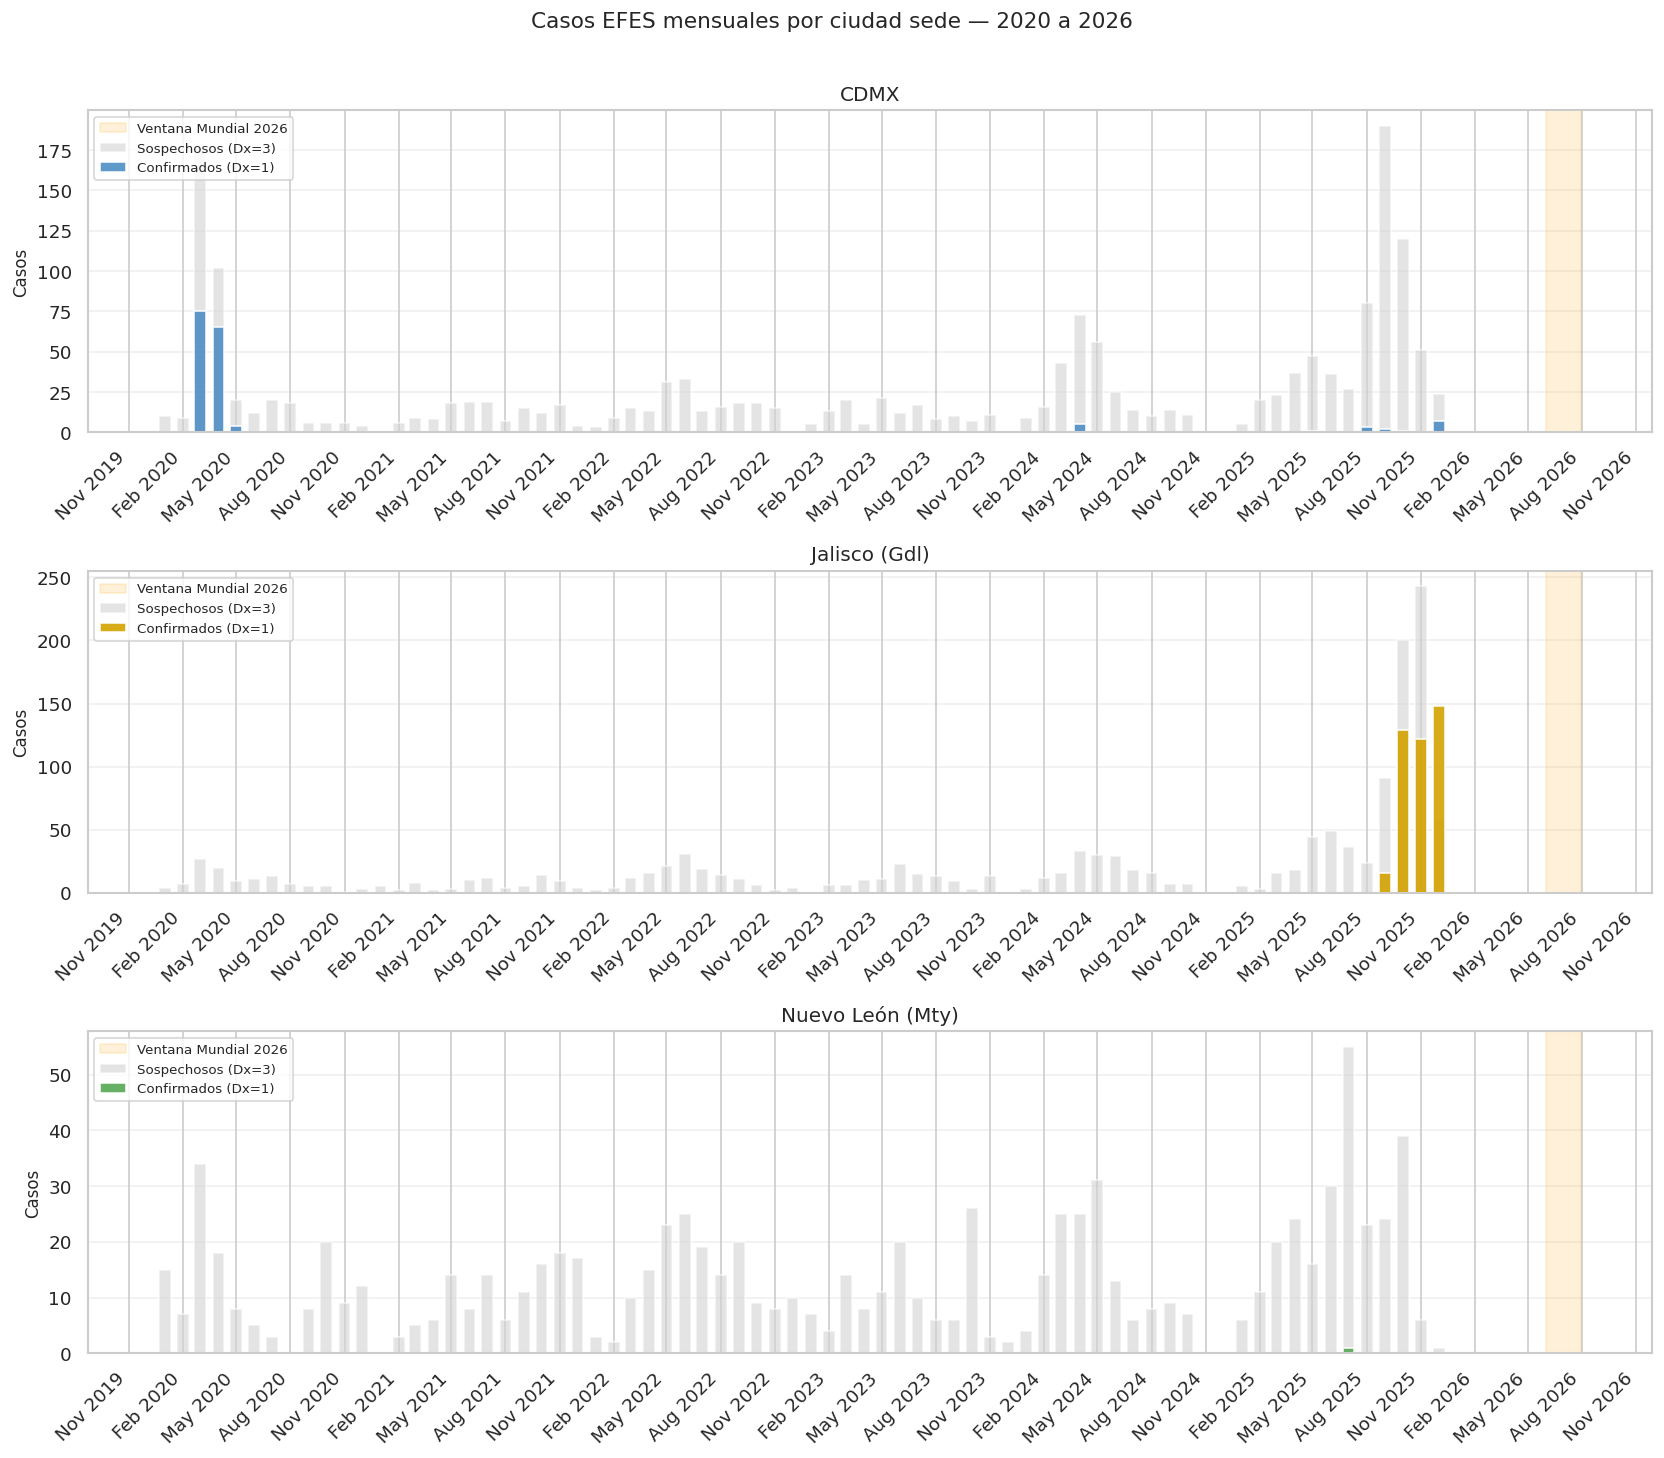

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

colores = {'CDMX': '#4e8ec4', 'Jalisco (Gdl)': '#d4a200', 'Nuevo León (Mty)': '#55a855'}

for ax, (entidad, nombre) in zip(axes, SEDES.items()):
    df_sede = monthly[monthly['ENTIDAD_RES'] == entidad].sort_values('anio_mes_dt')

    ax.bar(df_sede['anio_mes_dt'], df_sede['casos_sospechosos'],
           width=20, color='lightgray', alpha=0.6, label='Sospechosos (Dx=3)')
    ax.bar(df_sede['anio_mes_dt'], df_sede['casos_confirmados'],
           width=20, color=colores[nombre], alpha=0.9, label='Confirmados (Dx=1)')

    # Ventana del Mundial
    ax.axvspan(pd.Timestamp('2026-06-01'), pd.Timestamp('2026-07-31'),
               alpha=0.15, color='orange', label='Ventana Mundial 2026')

    ax.set_title(f'{nombre}', fontsize=12)
    ax.set_ylabel('Casos', fontsize=10)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Casos EFES mensuales por ciudad sede — 2020 a 2026', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + 'efes_serie_temporal_sedes.png', dpi=150, bbox_inches='tight')
plt.show()

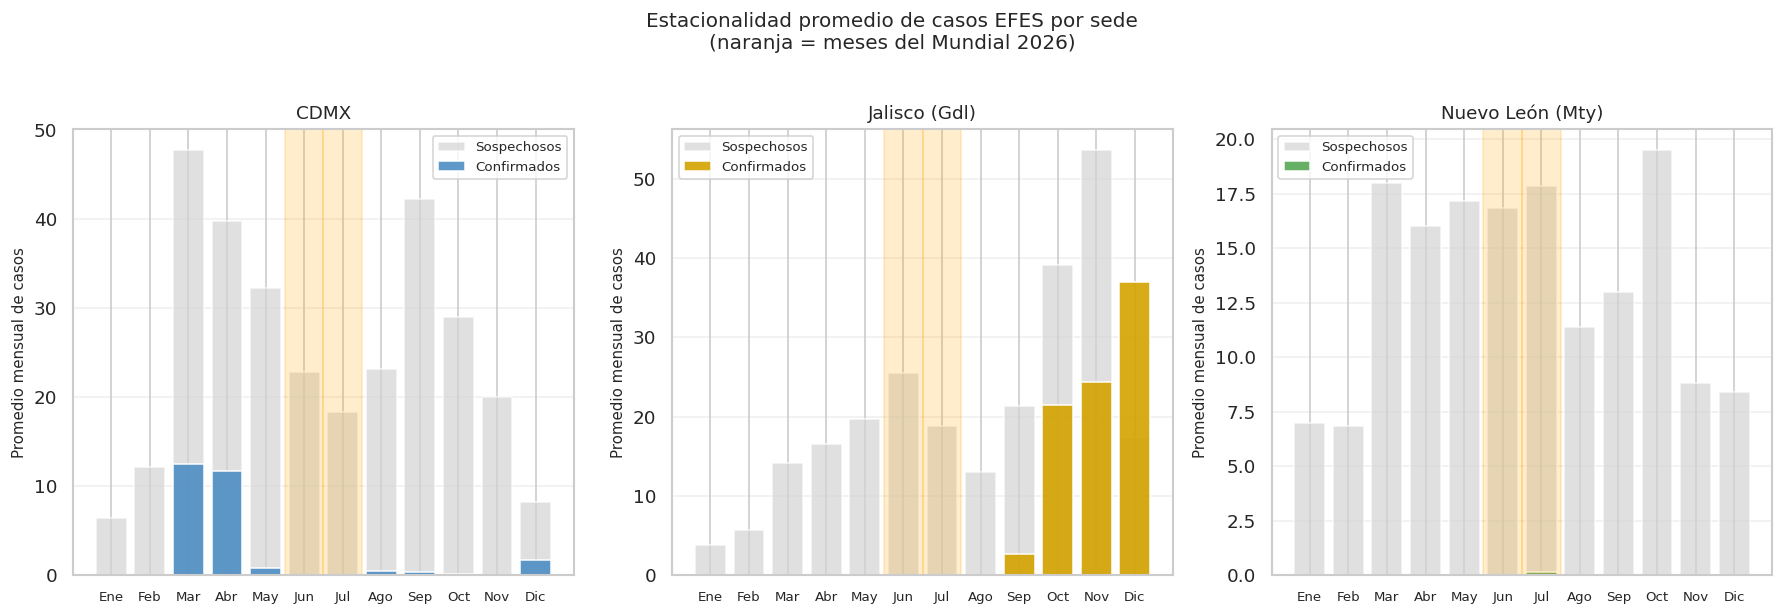

In [ ]:
# ¿En qué meses del año se concentran más casos históricamente?
monthly['mes_num'] = monthly['anio_mes_dt'].dt.month
monthly['mes_nombre'] = monthly['anio_mes_dt'].dt.strftime('%b')

estacionalidad = (
    monthly
    .groupby(['ENTIDAD_RES', 'sede', 'mes_num', 'mes_nombre'])
    [['casos_confirmados', 'casos_sospechosos']]
    .mean()
    .reset_index()
    .sort_values(['ENTIDAD_RES', 'mes_num'])
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
meses_label = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

for ax, (entidad, nombre) in zip(axes, SEDES.items()):
    d = estacionalidad[estacionalidad['ENTIDAD_RES'] == entidad]
    x = range(1, 13)

    ax.bar(x, d['casos_sospechosos'], color='lightgray', alpha=0.7,
           label='Sospechosos', width=0.8)
    ax.bar(x, d['casos_confirmados'], color=colores[nombre], alpha=0.9,
           label='Confirmados', width=0.8)

    # Resaltar junio-julio (Mundial)
    for m in [6, 7]:
        ax.axvspan(m - 0.5, m + 0.5, alpha=0.2, color='orange')

    ax.set_xticks(x)
    ax.set_xticklabels(meses_label, fontsize=8)
    ax.set_title(nombre, fontsize=11)
    ax.set_ylabel('Promedio mensual de casos', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Estacionalidad promedio de casos EFES por sede\n(naranja = meses del Mundial 2026)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + 'efes_estacionalidad_sedes.png', dpi=150, bbox_inches='tight')
plt.show()

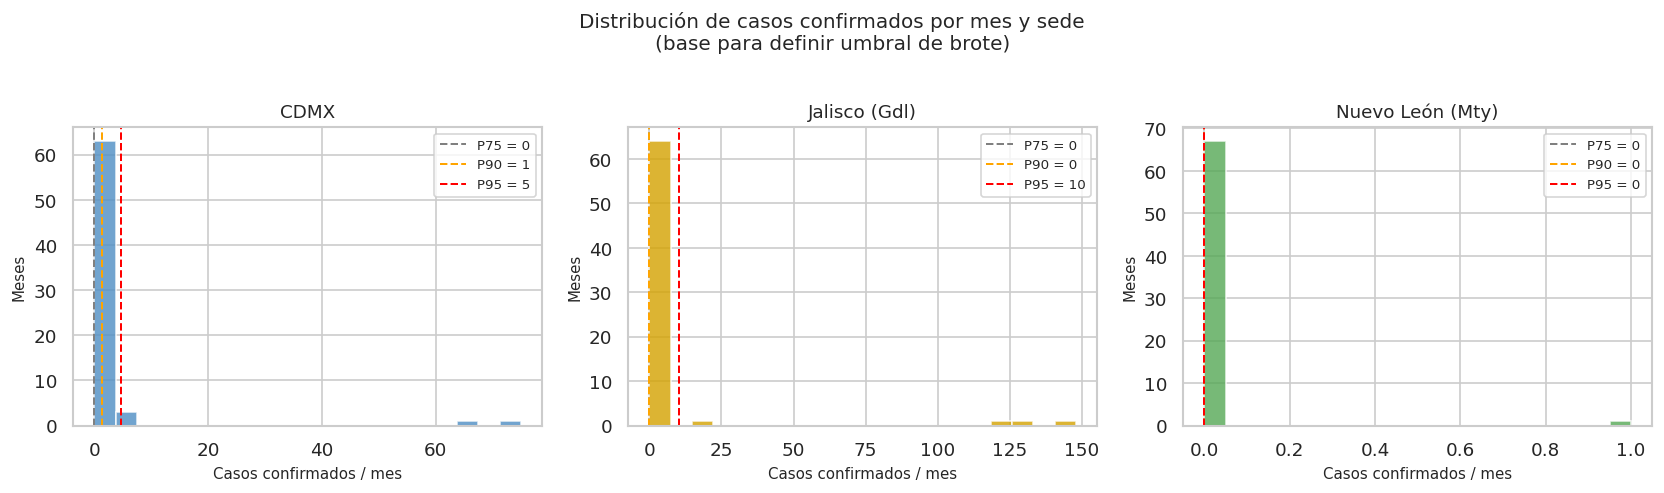


Estadísticos por sede:
       CDMX  Jalisco (Gdl)  Nuevo León (Mty)
P75    0.00            0.0              0.00
P90    1.30            0.0              0.00
P95    4.65           10.4              0.00
media  2.40            6.1              0.01

→ El umbral de brote se definirá como el percentil que decidas después de ver estos valores.
  Candidatos comunes: P90 (pocos falsos positivos) o P75 (más sensible).


In [ ]:
# Explorar distribución de casos confirmados mensuales para decidir el umbral
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

umbrales = {}

for ax, (entidad, nombre) in zip(axes, SEDES.items()):
    d = monthly[monthly['ENTIDAD_RES'] == entidad]['casos_confirmados']

    ax.hist(d, bins=20, color=colores[nombre], alpha=0.8, edgecolor='white')

    # Estadísticos clave
    p75 = d.quantile(0.75)
    p90 = d.quantile(0.90)
    p95 = d.quantile(0.95)
    media = d.mean()

    ax.axvline(p75, color='gray',   linestyle='--', linewidth=1.2, label=f'P75 = {p75:.0f}')
    ax.axvline(p90, color='orange', linestyle='--', linewidth=1.2, label=f'P90 = {p90:.0f}')
    ax.axvline(p95, color='red',    linestyle='--', linewidth=1.2, label=f'P95 = {p95:.0f}')

    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel('Casos confirmados / mes', fontsize=9)
    ax.set_ylabel('Meses', fontsize=9)
    ax.legend(fontsize=8)

    umbrales[nombre] = {'P75': p75, 'P90': p90, 'P95': p95, 'media': media}

plt.suptitle('Distribución de casos confirmados por mes y sede\n(base para definir umbral de brote)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + 'efes_distribucion_umbral.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nEstadísticos por sede:')
print(pd.DataFrame(umbrales).round(2).to_string())
print('\n→ El umbral de brote se definirá como el percentil que decidas después de ver estos valores.')
print('  Candidatos comunes: P90 (pocos falsos positivos) o P75 (más sensible).')

---
## 3. Isolation Forest — Detección de meses anómalos

**Isolation Forest** detecta anomalías aislando observaciones difíciles de
alcanzar mediante particiones aleatorias del espacio de features.
Un mes es anómalo si se necesitan pocas particiones para aislarlo —
es decir, es muy diferente al resto.

Entrenamos un modelo **por sede** usando las siguientes features mensuales:
- `casos_confirmados` — señal principal
- `casos_sospechosos` — señal de alerta temprana
- `tasa_confirmacion` — proporción de casos que se confirman
- `total_registros`   — volumen total de notificaciones

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

IF_FEATURES = [
    'casos_confirmados',
    'casos_sospechosos',
    'tasa_confirmacion',
    'total_registros',
]

# Resultado acumulado
anomalias_if = []

for entidad, nombre in SEDES.items():
    df_sede = (
        monthly[monthly['ENTIDAD_RES'] == entidad]
        .sort_values('anio_mes_dt')
        .copy()
    )

    X = df_sede[IF_FEATURES].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # contamination = proporción esperada de anomalías
    # Empezamos con 0.10 (10% de meses) — ajustable según umbral del EDA
    iso = IsolationForest(
        n_estimators=200,
        contamination=0.10,
        random_state=42
    )
    df_sede['if_label']  = iso.fit_predict(X_scaled)   # -1 = anomalía, 1 = normal
    df_sede['if_score']  = iso.score_samples(X_scaled)  # más negativo = más anómalo
    df_sede['anomalia_if'] = df_sede['if_label'] == -1

    anomalias_if.append(df_sede)
    n_anomalias = df_sede['anomalia_if'].sum()
    print(f'{nombre}: {n_anomalias} meses anómalos de {len(df_sede)} total')
    print(
        df_sede[df_sede['anomalia_if']]
        [['anio_mes', 'casos_confirmados', 'casos_sospechosos', 'if_score']]
        .sort_values('if_score')
        .to_string(index=False)
    )
    print()

monthly_if = pd.concat(anomalias_if, ignore_index=True)

CDMX: 7 meses anómalos de 68 total
anio_mes  casos_confirmados  casos_sospechosos  if_score
 2020-03                 75                176 -0.784772
 2020-04                 65                102 -0.780486
 2025-09                  2                190 -0.726514
 2025-12                  7                 24 -0.678953
 2025-10                  1                120 -0.651544
 2024-04                  5                 73 -0.647510
 2020-05                  4                 20 -0.637633

Jalisco (Gdl): 7 meses anómalos de 68 total
anio_mes  casos_confirmados  casos_sospechosos  if_score
 2025-12                148                 58 -0.808035
 2025-11                122                243 -0.782984
 2025-10                129                200 -0.762876
 2025-09                 16                 91 -0.760096
 2025-06                  0                 49 -0.620948
 2025-05                  0                 44 -0.579036
 2025-07                  0                 36 -0.533006

Nuevo L

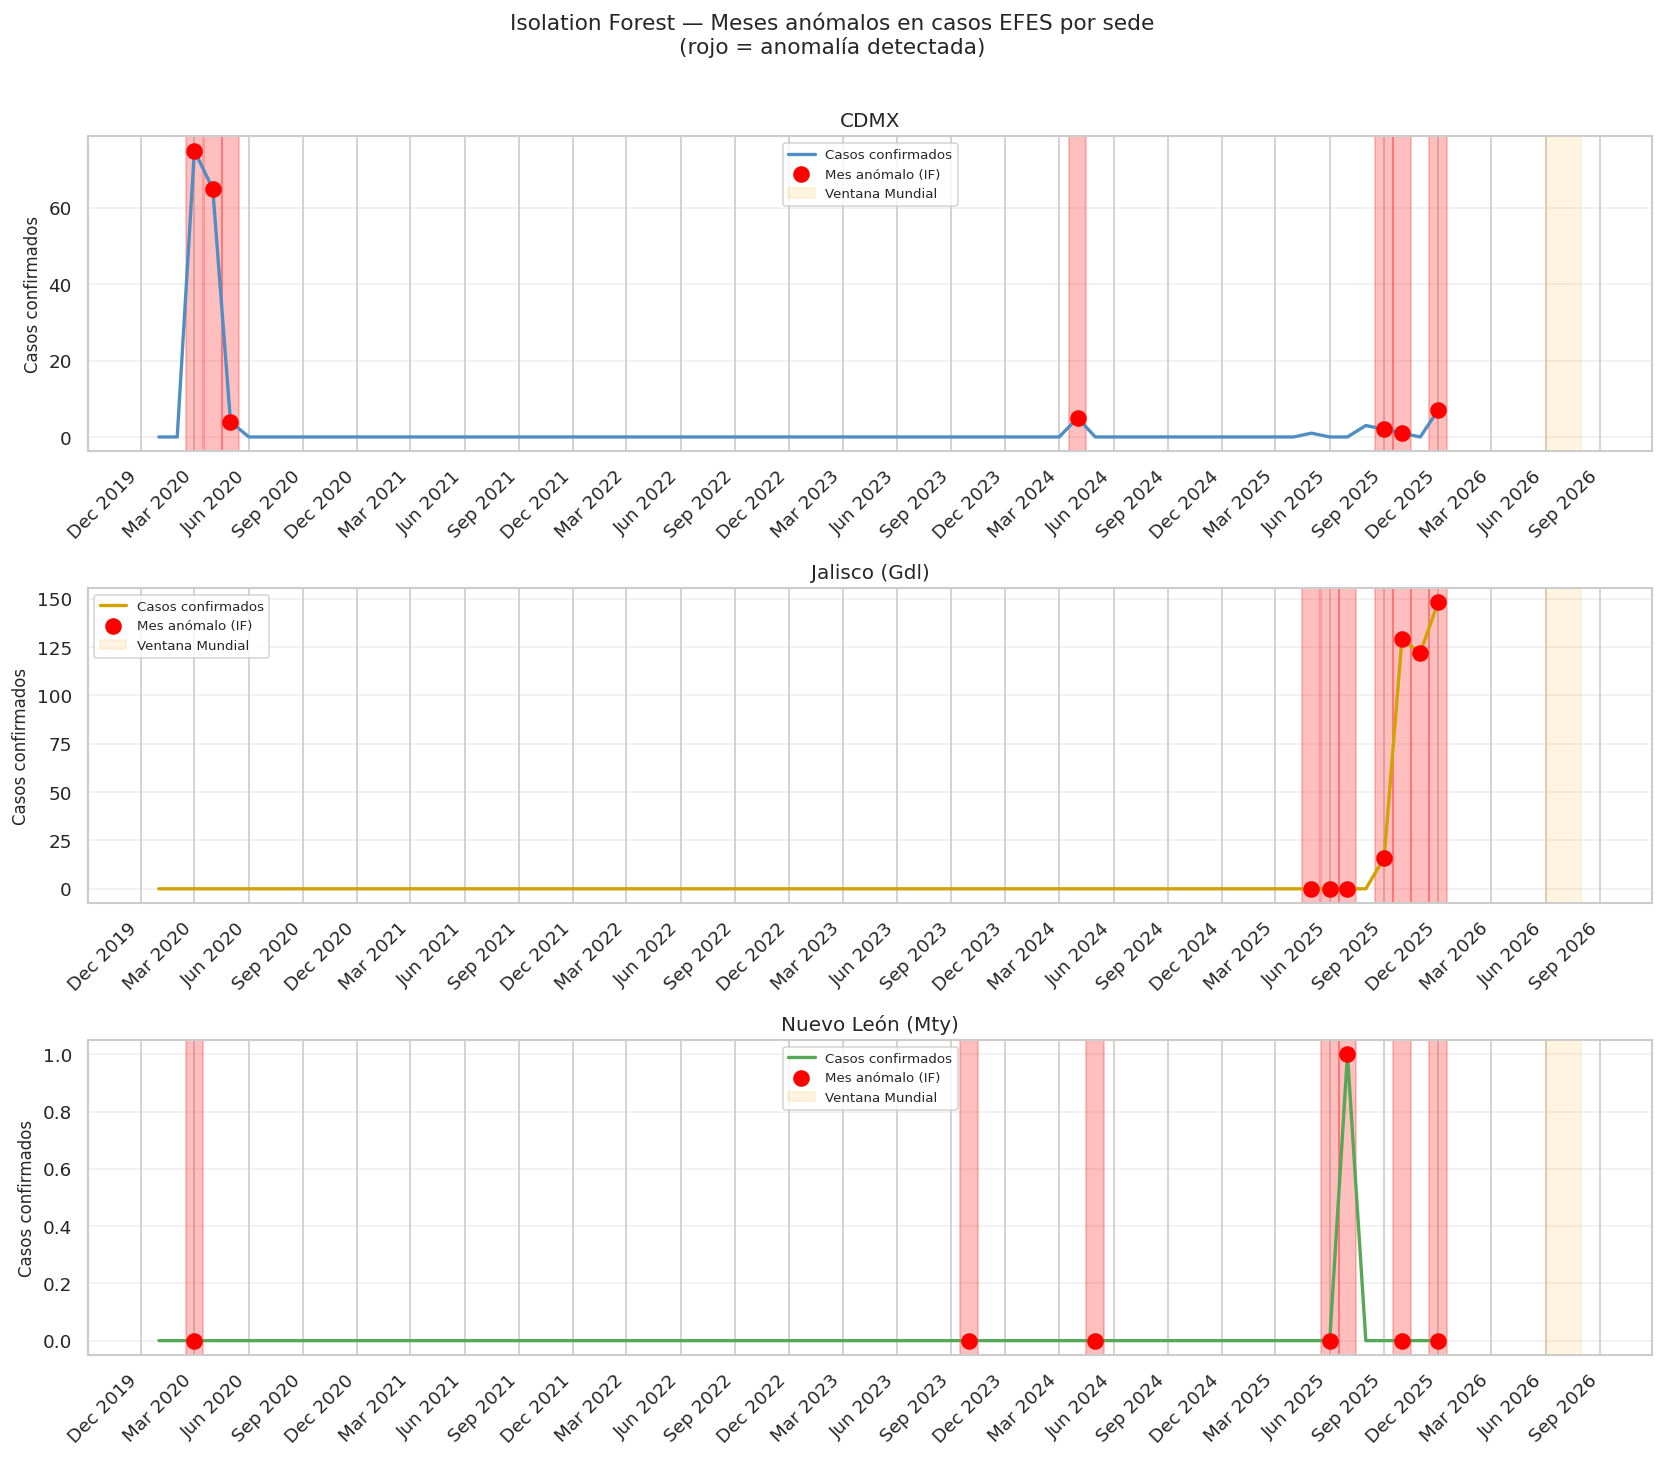

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, (entidad, nombre) in zip(axes, SEDES.items()):
    d = monthly_if[monthly_if['ENTIDAD_RES'] == entidad].sort_values('anio_mes_dt')

    # Fondo para meses anómalos
    for _, row in d[d['anomalia_if']].iterrows():
        ax.axvspan(
            row['anio_mes_dt'] - pd.Timedelta(days=15),
            row['anio_mes_dt'] + pd.Timedelta(days=15),
            alpha=0.25, color='red'
        )

    ax.plot(d['anio_mes_dt'], d['casos_confirmados'],
            color=colores[nombre], linewidth=2, label='Casos confirmados')
    ax.scatter(
        d[d['anomalia_if']]['anio_mes_dt'],
        d[d['anomalia_if']]['casos_confirmados'],
        color='red', s=80, zorder=5, label='Mes anómalo (IF)'
    )

    # Ventana Mundial
    ax.axvspan(pd.Timestamp('2026-06-01'), pd.Timestamp('2026-07-31'),
               alpha=0.12, color='orange', label='Ventana Mundial')

    ax.set_title(nombre, fontsize=12)
    ax.set_ylabel('Casos confirmados', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Isolation Forest — Meses anómalos en casos EFES por sede\n(rojo = anomalía detectada)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + 'if_anomalias_sedes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. DBSCAN — Validación de anomalías por densidad

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise)
agrupa puntos por densidad. Los puntos que no pertenecen a ningún cluster
son etiquetados como **ruido (label = -1)** — estos son nuestros meses anómalos.

A diferencia de Isolation Forest, DBSCAN no requiere especificar la
proporción de anomalías. La detección emerge de la estructura de los datos.

Usamos los mismos features que en Isolation Forest para poder comparar
directamente los resultados de ambos métodos.

In [ ]:
from sklearn.cluster import DBSCAN

# eps y min_samples se ajustan por sede según densidad de los datos
# Valores iniciales conservadores — ajustar si hay pocos clusters
DBSCAN_PARAMS = {
    9:  {'eps': 1.2, 'min_samples': 2},
    14: {'eps': 1.2, 'min_samples': 2},
    19: {'eps': 1.2, 'min_samples': 2},
}

anomalias_db = []

for entidad, nombre in SEDES.items():
    df_sede = (
        monthly_if[monthly_if['ENTIDAD_RES'] == entidad]
        .sort_values('anio_mes_dt')
        .copy()
    )

    X = df_sede[IF_FEATURES].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    params = DBSCAN_PARAMS[entidad]
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    df_sede['db_label']    = db.fit_predict(X_scaled)
    df_sede['anomalia_db'] = df_sede['db_label'] == -1

    anomalias_db.append(df_sede)

    n_clusters  = df_sede[df_sede['db_label'] >= 0]['db_label'].nunique()
    n_anomalias = df_sede['anomalia_db'].sum()
    print(f'{nombre}: {n_clusters} clusters, {n_anomalias} meses ruido (anómalos)')
    print(
        df_sede[df_sede['anomalia_db']]
        [['anio_mes', 'casos_confirmados', 'casos_sospechosos', 'db_label']]
        .to_string(index=False)
    )
    print()

monthly_final = pd.concat(anomalias_db, ignore_index=True)

CDMX: 2 clusters, 4 meses ruido (anómalos)
anio_mes  casos_confirmados  casos_sospechosos  db_label
 2020-03                 75                176        -1
 2020-04                 65                102        -1
 2025-09                  2                190        -1
 2025-10                  1                120        -1

Jalisco (Gdl): 1 clusters, 4 meses ruido (anómalos)
anio_mes  casos_confirmados  casos_sospechosos  db_label
 2025-09                 16                 91        -1
 2025-10                129                200        -1
 2025-11                122                243        -1
 2025-12                148                 58        -1

Nuevo León (Mty): 1 clusters, 1 meses ruido (anómalos)
anio_mes  casos_confirmados  casos_sospechosos  db_label
 2025-07                  1                 55        -1



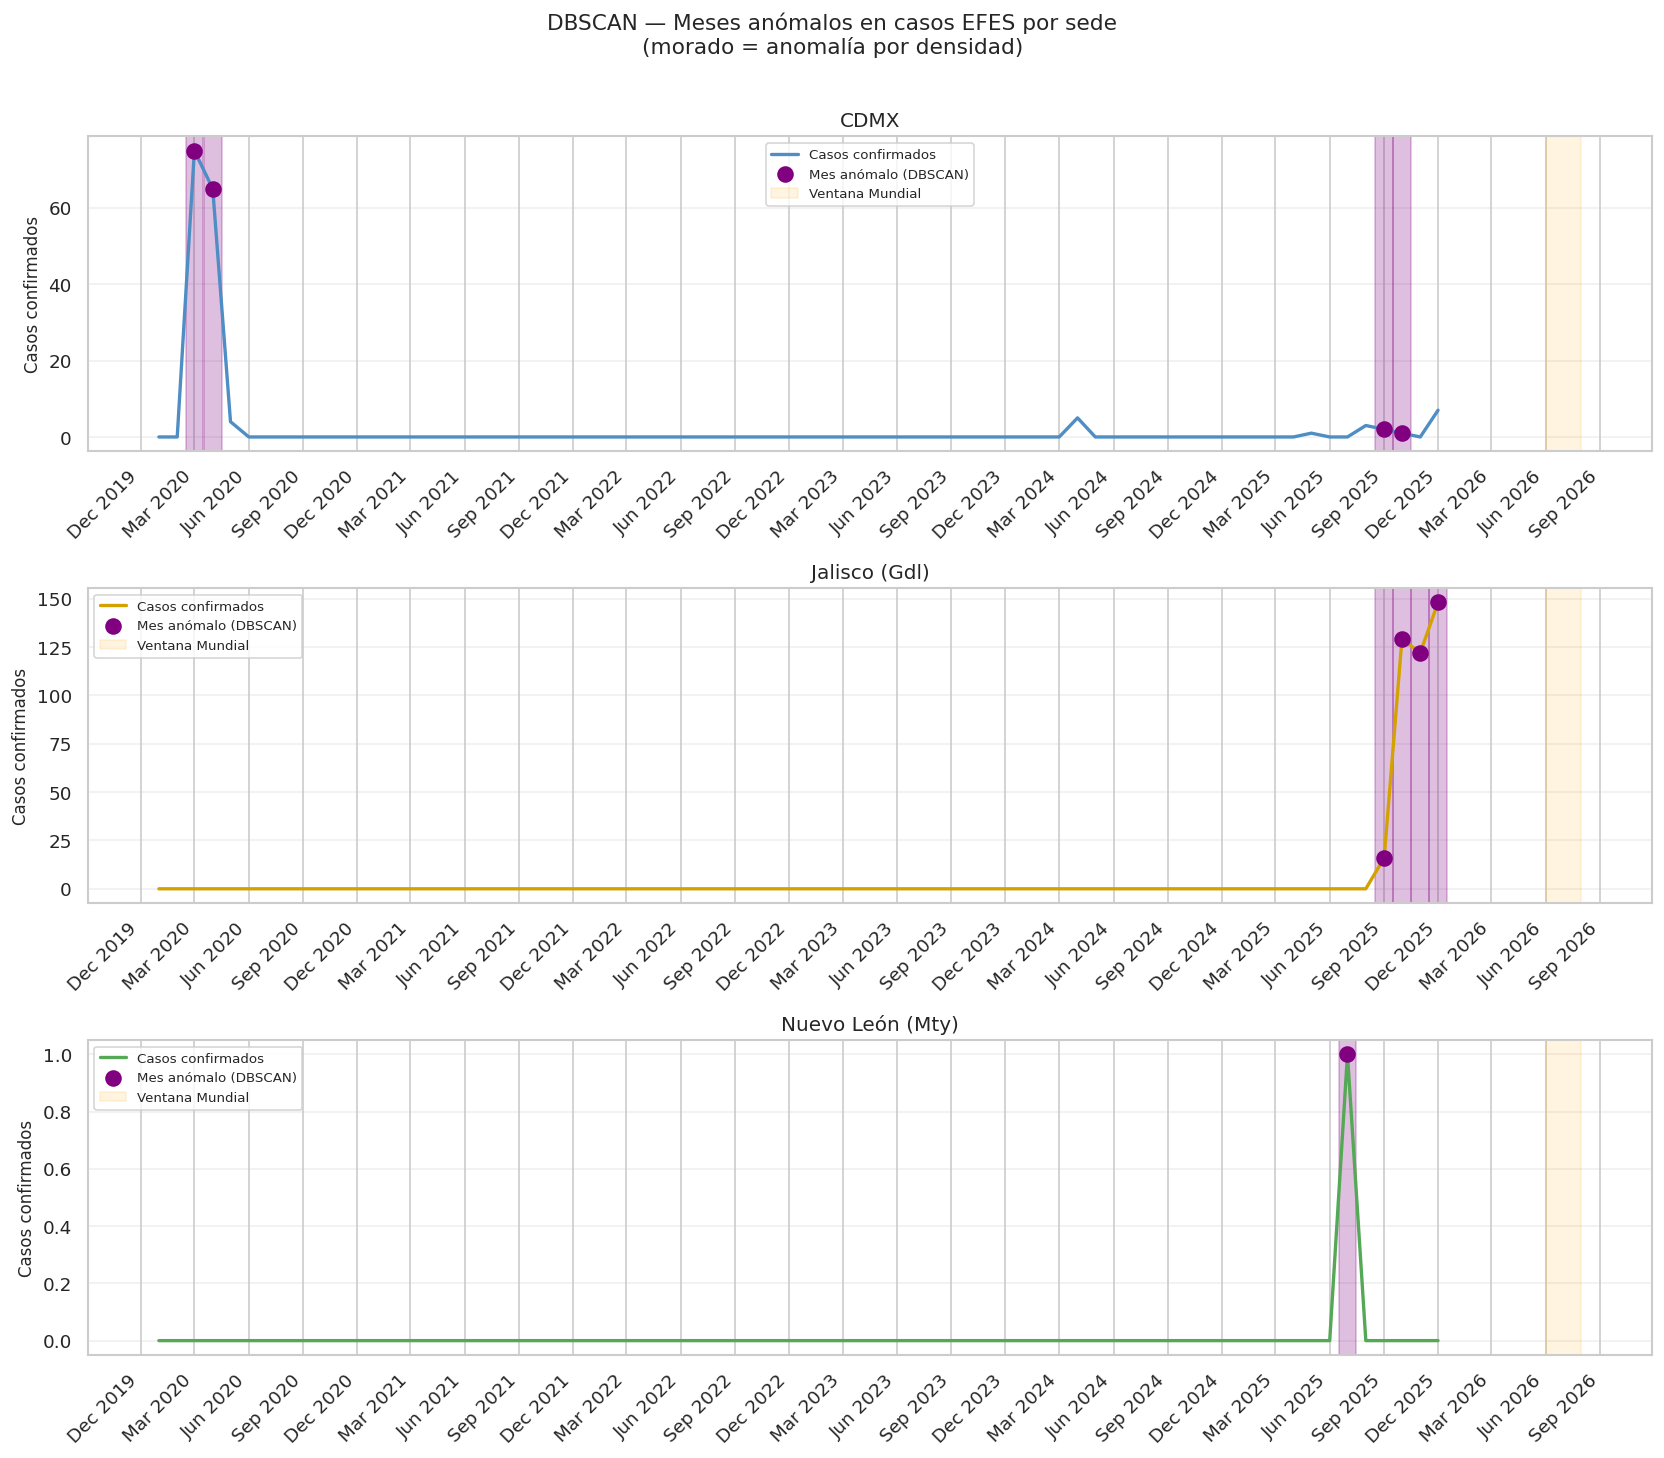

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, (entidad, nombre) in zip(axes, SEDES.items()):
    d = monthly_final[monthly_final['ENTIDAD_RES'] == entidad].sort_values('anio_mes_dt')

    for _, row in d[d['anomalia_db']].iterrows():
        ax.axvspan(
            row['anio_mes_dt'] - pd.Timedelta(days=15),
            row['anio_mes_dt'] + pd.Timedelta(days=15),
            alpha=0.25, color='purple'
        )

    ax.plot(d['anio_mes_dt'], d['casos_confirmados'],
            color=colores[nombre], linewidth=2, label='Casos confirmados')
    ax.scatter(
        d[d['anomalia_db']]['anio_mes_dt'],
        d[d['anomalia_db']]['casos_confirmados'],
        color='purple', s=80, zorder=5, label='Mes anómalo (DBSCAN)'
    )
    ax.axvspan(pd.Timestamp('2026-06-01'), pd.Timestamp('2026-07-31'),
               alpha=0.12, color='orange', label='Ventana Mundial')

    ax.set_title(nombre, fontsize=12)
    ax.set_ylabel('Casos confirmados', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('DBSCAN — Meses anómalos en casos EFES por sede\n(morado = anomalía por densidad)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + 'dbscan_anomalias_sedes.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("Variables disponibles relacionadas con EFES:")
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame) and any(
        c in obj.columns for c in ['anomalia_if', 'anomalia_db', 'casos_confirmados', 'ENTIDAD_RES']
    ):
        print(f"  {name}: {obj.shape} | cols: {obj.columns.tolist()[:6]}")

Variables disponibles relacionadas con EFES:
  df: (18595, 23) | cols: ['FECHA_ACTUALIZACION', 'ID_REGISTRO', 'EDAD_ANOS', 'EDAD_MESES', 'EDAD_DIAS', 'SEXO']
  efes: (23708, 24) | cols: ['FECHA_ACTUALIZACION', 'ID_REGISTRO', 'EDAD_ANOS', 'EDAD_MESES', 'EDAD_DIAS', 'SEXO']
  efes_sedes: (4675, 25) | cols: ['FECHA_ACTUALIZACION', 'ID_REGISTRO', 'EDAD_ANOS', 'EDAD_MESES', 'EDAD_DIAS', 'SEXO']
  monthly: (204, 14) | cols: ['anio_mes', 'ENTIDAD_RES', 'sede', 'casos_confirmados', 'casos_sospechosos', 'casos_descartados']
  _6: (9, 12) | cols: ['anio_mes', 'ENTIDAD_RES', 'sede', 'casos_confirmados', 'casos_sospechosos', 'casos_descartados']
  df_sede: (68, 19) | cols: ['anio_mes', 'ENTIDAD_RES', 'sede', 'casos_confirmados', 'casos_sospechosos', 'casos_descartados']
  estacionalidad: (36, 6) | cols: ['ENTIDAD_RES', 'sede', 'mes_num', 'mes_nombre', 'casos_confirmados', 'casos_sospechosos']
  d: (68, 19) | cols: ['anio_mes', 'ENTIDAD_RES', 'sede', 'casos_confirmados', 'casos_sospechosos', 'casos

---
## 5. Comparación IF vs DBSCAN y definición del target `brote`

Comparamos qué meses detecta cada método. Los meses que **ambos métodos
coinciden** son los candidatos más robustos a ser etiquetados como `brote = 1`.

Regla de decisión:
- `brote = 1` si **IF o DBSCAN** lo detectan como anómalo (regla laxa, más recall)
- `brote_estricto = 1` si **ambos métodos** coinciden (regla estricta, más precisión)

In [ ]:
from sklearn.metrics import cohen_kappa_score

print('=== Concordancia entre métodos ===\n')

resumen_brotes = []

for entidad, nombre in SEDES.items():
    d = monthly_final[monthly_final['ENTIDAD_RES'] == entidad].copy()

    solo_if   = (d['anomalia_if'] & ~d['anomalia_db']).sum()
    solo_db   = (~d['anomalia_if'] & d['anomalia_db']).sum()
    ambos     = (d['anomalia_if'] & d['anomalia_db']).sum()
    ninguno   = (~d['anomalia_if'] & ~d['anomalia_db']).sum()

    kappa = cohen_kappa_score(d['anomalia_if'], d['anomalia_db'])

    print(f'{nombre}:')
    print(f'  Solo IF:    {solo_if} meses')
    print(f'  Solo DBSCAN:{solo_db} meses')
    print(f'  Ambos:      {ambos} meses  ← candidatos brote_estricto=1')
    print(f'  Ninguno:    {ninguno} meses')
    print(f'  Cohen Kappa: {kappa:.3f}')
    print()

    d['brote']         = (d['anomalia_if'] | d['anomalia_db']).astype(int)
    d['brote_estricto']= (d['anomalia_if'] & d['anomalia_db']).astype(int)
    resumen_brotes.append(d)

monthly_target = pd.concat(resumen_brotes, ignore_index=True)

print(f'Total meses con brote=1 (laxa):    {monthly_target["brote"].sum()}')
print(f'Total meses con brote=1 (estricta): {monthly_target["brote_estricto"].sum()}')

=== Concordancia entre métodos ===

CDMX:
  Solo IF:    3 meses
  Solo DBSCAN:0 meses
  Ambos:      4 meses  ← candidatos brote_estricto=1
  Ninguno:    61 meses
  Cohen Kappa: 0.705

Jalisco (Gdl):
  Solo IF:    3 meses
  Solo DBSCAN:0 meses
  Ambos:      4 meses  ← candidatos brote_estricto=1
  Ninguno:    61 meses
  Cohen Kappa: 0.705

Nuevo León (Mty):
  Solo IF:    6 meses
  Solo DBSCAN:0 meses
  Ambos:      1 meses  ← candidatos brote_estricto=1
  Ninguno:    61 meses
  Cohen Kappa: 0.230

Total meses con brote=1 (laxa):    21
Total meses con brote=1 (estricta): 9


In [ ]:
from sklearn.metrics import cohen_kappa_score

resumen_brotes = []

for entidad, nombre in SEDES.items():
    d = monthly_final[monthly_final['ENTIDAD_RES'] == entidad].copy()

    d['brote']          = (d['anomalia_if'] | d['anomalia_db']).astype(int)
    d['brote_estricto'] = (d['anomalia_if'] & d['anomalia_db']).astype(int)
    resumen_brotes.append(d)

monthly_target = pd.concat(resumen_brotes, ignore_index=True)

print("Columnas disponibles:", monthly_target.columns.tolist())
print(monthly_target.groupby('sede')[['brote','brote_estricto']].sum())

Columnas disponibles: ['anio_mes', 'ENTIDAD_RES', 'sede', 'casos_confirmados', 'casos_sospechosos', 'casos_descartados', 'total_registros', 'vacunados', 'con_complicaciones', 'defunciones', 'anio_mes_dt', 'tasa_confirmacion', 'mes_num', 'mes_nombre', 'if_label', 'if_score', 'anomalia_if', 'db_label', 'anomalia_db', 'brote', 'brote_estricto']
                  brote  brote_estricto
sede                                   
CDMX                  7               4
Jalisco (Gdl)         7               4
Nuevo León (Mty)      7               1


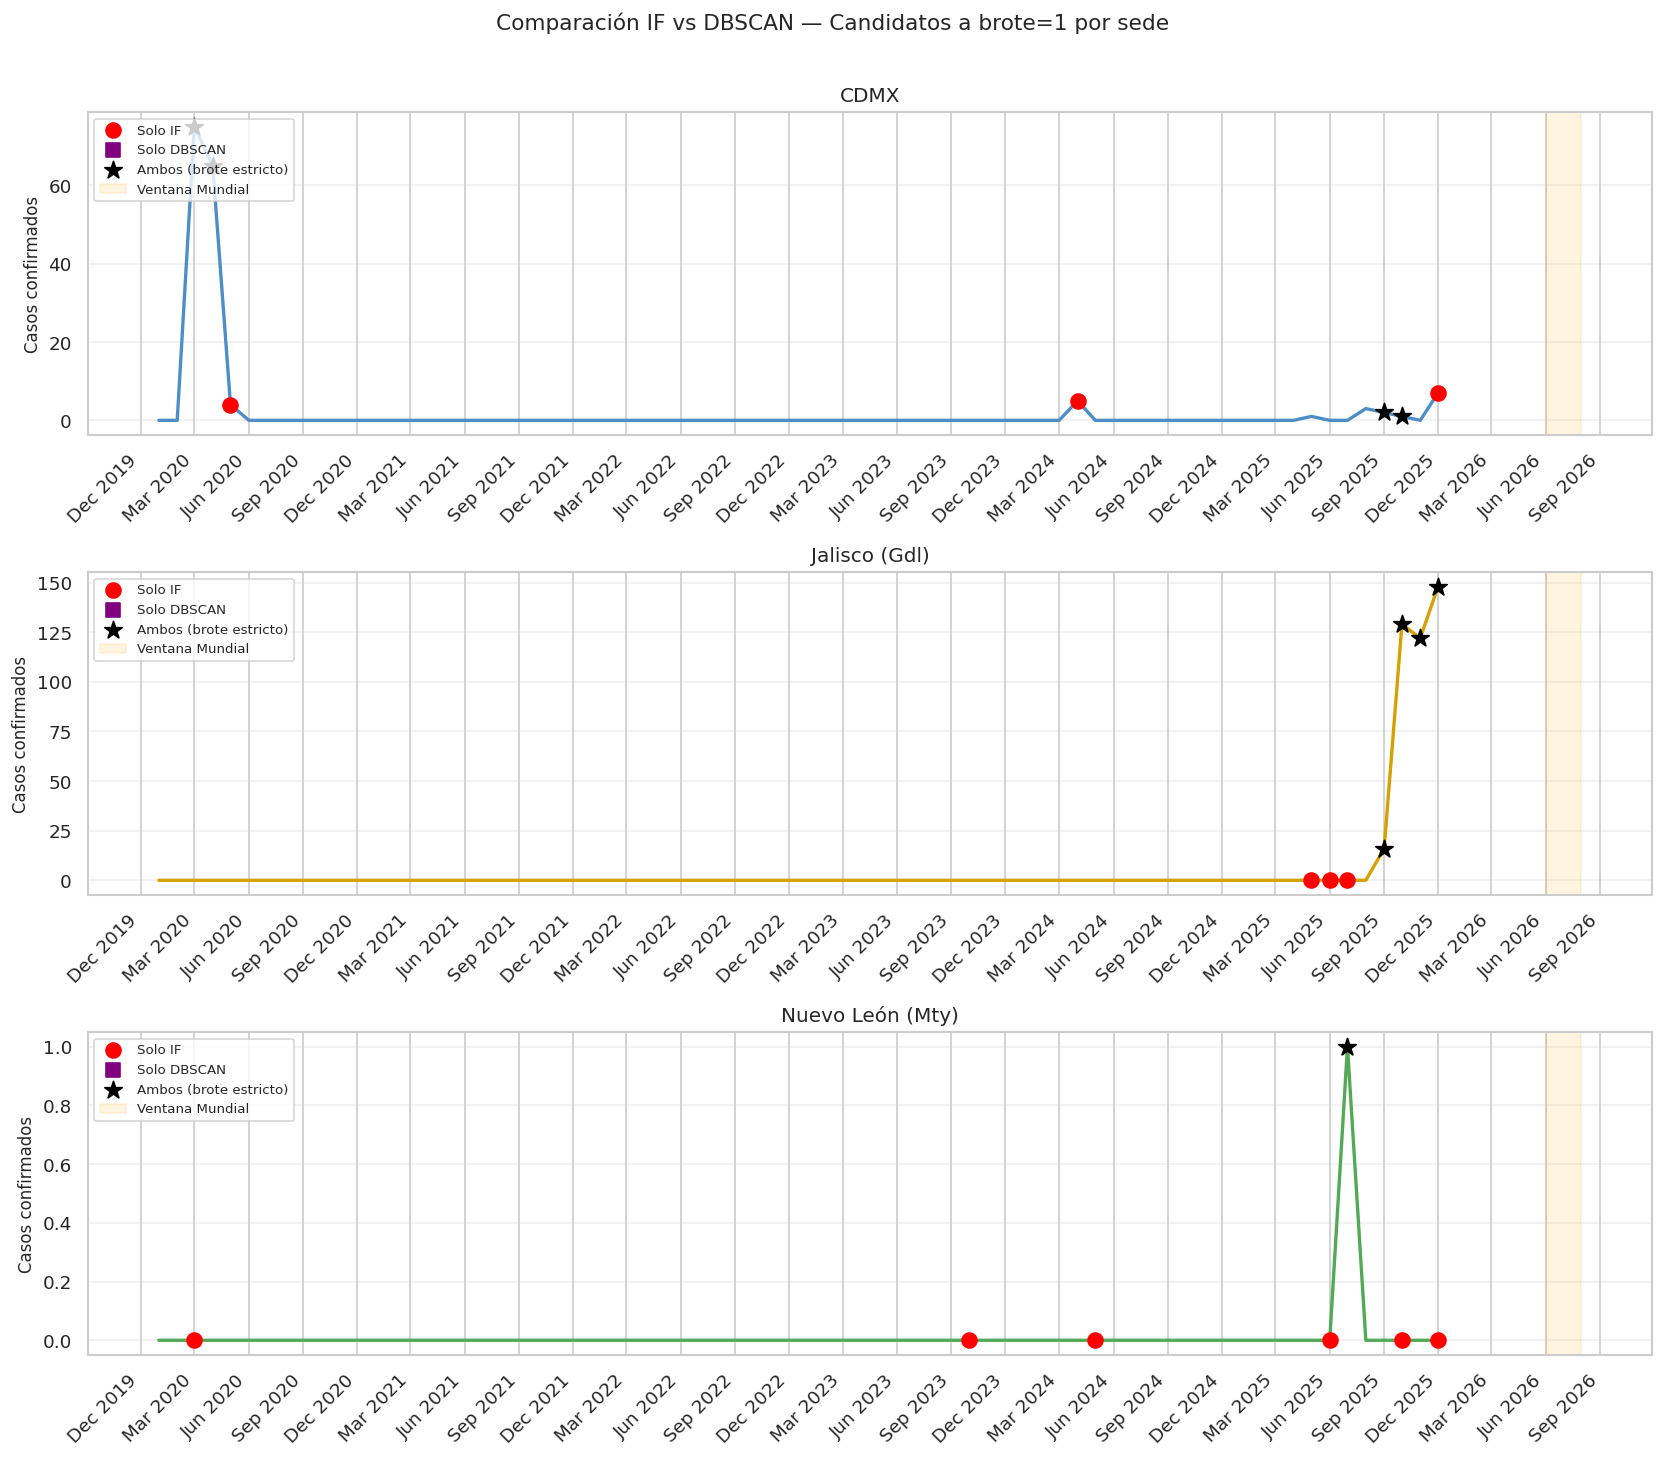

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, (entidad, nombre) in zip(axes, SEDES.items()):
    d = monthly_target[monthly_target['ENTIDAD_RES'] == entidad].sort_values('anio_mes_dt')

    ax.plot(d['anio_mes_dt'], d['casos_confirmados'],
            color=colores[nombre], linewidth=2, zorder=2)

    # Solo IF
    solo_if = d[d['anomalia_if'] & ~d['anomalia_db']]
    ax.scatter(solo_if['anio_mes_dt'], solo_if['casos_confirmados'],
               color='red', s=80, marker='o', label='Solo IF', zorder=4)

    # Solo DBSCAN
    solo_db = d[~d['anomalia_if'] & d['anomalia_db']]
    ax.scatter(solo_db['anio_mes_dt'], solo_db['casos_confirmados'],
               color='purple', s=80, marker='s', label='Solo DBSCAN', zorder=4)

    # Ambos
    ambos = d[d['brote_estricto'] == 1]
    ax.scatter(ambos['anio_mes_dt'], ambos['casos_confirmados'],
               color='black', s=120, marker='*', label='Ambos (brote estricto)', zorder=5)

    ax.axvspan(pd.Timestamp('2026-06-01'), pd.Timestamp('2026-07-31'),
               alpha=0.12, color='orange', label='Ventana Mundial')

    ax.set_title(nombre, fontsize=12)
    ax.set_ylabel('Casos confirmados', fontsize=10)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Comparación IF vs DBSCAN — Candidatos a brote=1 por sede',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + 'comparacion_if_dbscan.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Exportar serie mensual con labels de brote
cols_export = [
    'anio_mes', 'anio_mes_dt', 'ENTIDAD_RES', 'sede',
    'casos_confirmados', 'casos_sospechosos', 'total_registros',
    'tasa_confirmacion', 'vacunados', 'con_complicaciones',
    'anomalia_if', 'if_score', 'anomalia_db', 'db_label',
    'brote', 'brote_estricto'
]

monthly_target[cols_export].to_csv(
    OUTPUT_DATA + 'efes_mensual_sedes_target.csv',
    index=False
)

print('Archivo exportado: efes_mensual_sedes_target.csv')
print(f'\nResumen final:')
print(
    monthly_target.groupby('sede')[['brote', 'brote_estricto']].sum()
    .rename(columns={'brote': 'brote_laxa', 'brote_estricto': 'brote_estricta'})
    .to_string()
)

Archivo exportado: efes_mensual_sedes_target.csv

Resumen final:
                  brote_laxa  brote_estricta
sede                                        
CDMX                       7               4
Jalisco (Gdl)              7               4
Nuevo León (Mty)           7               1


---
## 6. Conclusiones del Notebook 2

Responde estas preguntas después de correr el notebook:

1. **¿Qué meses históricos fueron detectados como anómalos por ambos métodos?**
   ¿Coinciden con eventos conocidos (brote de rubéola 2020, sarampión importado)?

2. **¿Qué sede muestra más meses anómalos?** ¿Jalisco (ya tiene 4,232 casos en 2026)?

3. **¿Qué regla de brote usarás?** ¿Laxa (IF o DBSCAN) o estricta (ambos)?
   Justifica con base en el recall que necesita el modelo.

4. **¿El Cohen Kappa entre métodos es alto o bajo?**
   Kappa > 0.6 indica buena concordancia — los dos métodos ven lo mismo.
   Kappa < 0.4 sugiere que capturan distintos tipos de anomalías.

5. **¿La ventana del Mundial (jun-jul 2026) ya muestra señal?**
   Los datos de 2026 llegan hasta marzo — ¿hay tendencia creciente hacia ese período?

### Siguiente paso
El archivo `efes_mensual_sedes_target.csv` se une en el Notebook 3 con los
datos de pasajeros internacionales para analizar si el flujo de viajeros
precede a los brotes (análisis de correlación con lag temporal).

In [ ]:
print("=== ANOMALÍAS POR SEDE ===")
for entidad, nombre in SEDES.items():
    d = monthly_target[monthly_target['ENTIDAD_RES'] == entidad]
    print(f"\n{nombre}:")
    print(f"  Total meses: {len(d)}")
    print(f"  Brote laxa:     {d['brote'].sum()}")
    print(f"  Brote estricto: {d['brote_estricto'].sum()}")
    print(f"  Meses con brote_estricto=1:")
    print(d[d['brote_estricto']==1][['anio_mes','casos_confirmados','if_score']].to_string(index=False))

print("\n=== UMBRALES POR SEDE ===")
print(pd.DataFrame(umbrales).round(2))

print("\n=== COHEN KAPPA POR SEDE ===")
for entidad, nombre in SEDES.items():
    d = monthly_target[monthly_target['ENTIDAD_RES'] == entidad]
    k = cohen_kappa_score(d['anomalia_if'], d['anomalia_db'])
    print(f"  {nombre}: kappa={k:.3f}")

=== ANOMALÍAS POR SEDE ===

CDMX:
  Total meses: 68
  Brote laxa:     7
  Brote estricto: 4
  Meses con brote_estricto=1:
anio_mes  casos_confirmados  if_score
 2020-03                 75 -0.784772
 2020-04                 65 -0.780486
 2025-09                  2 -0.726514
 2025-10                  1 -0.651544

Jalisco (Gdl):
  Total meses: 68
  Brote laxa:     7
  Brote estricto: 4
  Meses con brote_estricto=1:
anio_mes  casos_confirmados  if_score
 2025-09                 16 -0.760096
 2025-10                129 -0.762876
 2025-11                122 -0.782984
 2025-12                148 -0.808035

Nuevo León (Mty):
  Total meses: 68
  Brote laxa:     7
  Brote estricto: 1
  Meses con brote_estricto=1:
anio_mes  casos_confirmados  if_score
 2025-07                  1 -0.870443

=== UMBRALES POR SEDE ===
       CDMX  Jalisco (Gdl)  Nuevo León (Mty)
P75    0.00            0.0              0.00
P90    1.30            0.0              0.00
P95    4.65           10.4              0.00
medi